In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [8]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0,1] range
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


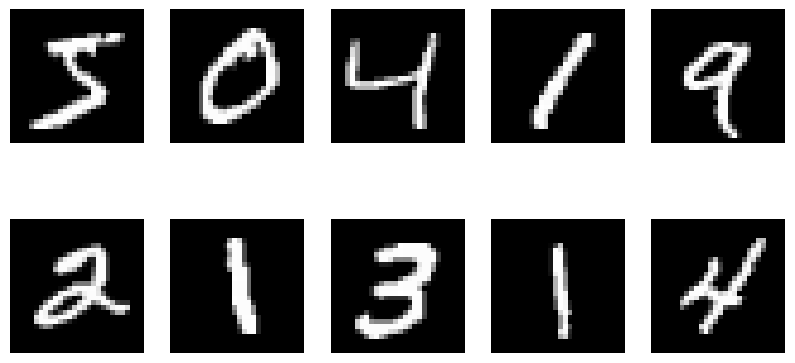

In [9]:
# Display some sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.show()

In [10]:
# Define a simple neural network model
model = keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(28, 28)),  # Flatten 28x28 images to 1D
        keras.layers.Dense(
            128, activation="relu"
        ),  # Fully connected layer with ReLU activation
        keras.layers.Dropout(0.2),  # Dropout for regularization
        keras.layers.Dense(
            10, activation="softmax"
        ),  # Output layer with softmax for classification
    ]
)

/opt/homebrew/Caskroom/miniconda/base/envs/mlenv/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-03-24 03:36:36.893590: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-03-24 03:36:36.893826: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-03-24 03:36:36.893831: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-03-24 03:36:36.893877: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-24 03:36:36.893933: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow devi

In [11]:
# Compile the model
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# Train the model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5


2025-03-24 03:36:59.138273: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8407 - loss: 0.5401 - val_accuracy: 0.9173 - val_loss: 0.3055
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8923 - loss: 0.3853 - val_accuracy: 0.9095 - val_loss: 0.3333
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8899 - loss: 0.4001 - val_accuracy: 0.9178 - val_loss: 0.3057
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8839 - loss: 0.4134 - val_accuracy: 0.9141 - val_loss: 0.3102
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8829 - loss: 0.4196 - val_accuracy: 0.9043 - val_loss: 0.3359


In [12]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8893 - loss: 0.3860

Test accuracy: 0.9043


In [1]:
# Save the model
model.save("mnist_model.h5")
print("\nModel saved as 'mnist_model.h5'")

NameError: name 'model' is not defined